# Unemployment Analysis and Prediction

Analyze unemployment trends across Indian states, visualize insights, study COVID-19 impact, and build a machine learning model to predict unemployment rates.


Install Required Libraries



In [1]:
!pip install pandas numpy matplotlib seaborn plotly scikit-learn xgboost gradio joblib

Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib
import gradio as gr
import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [3]:
df = pd.read_csv("Unemployment in India.csv")
df_2020 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df.columns = df.columns.str.strip()
df_2020.columns = df_2020.columns.str.strip()

df['Date'] = pd.to_datetime(
    df['Date'].astype(str).str.strip(),
    format='%d-%m-%Y',
    errors='coerce'
)

df_2020['Date'] = pd.to_datetime(
    df_2020['Date'].astype(str).str.strip(),
    format='%d-%m-%Y',
    errors='coerce'
)

Display Dataset

In [4]:
df.head()

df_2020.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


Dataset Information

In [5]:
df.info()

df_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                

Statistical Summary

In [6]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


In [74]:
df_2020.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,267,267.000000,2.670000e+02,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000
std,NaN,10.803283,1.336632e+07,7.845419


Dataset Shape

In [7]:
print(df.shape)

print(df_2020.shape)

(768, 7)
(267, 9)


In [8]:
print(df['Date'].isnull().sum())
print(df_2020['Date'].isnull().sum())

28
0


In [9]:
df.columns = df.columns.str.strip()
df_2020.columns = df_2020.columns.str.strip()

Remove Unnecessary Columns

In [10]:
df_2020 = df_2020.drop(
    columns=["Frequency","Region.1","longitude","latitude"],
    errors="ignore"
)

Check Missing Values

In [11]:
print(df['Date'].isnull().sum())
print(df_2020['Date'].isnull().sum())

28
0


Merge Datasets

In [12]:
combined_df = pd.concat(
    [df, df_2020],
    ignore_index=True
)

# Add Month, Month_int, Year columns to combined_df after concatenation
combined_df["Month_int"] = combined_df["Date"].dt.month
combined_df["Month"] = combined_df["Date"].dt.strftime("%B")
combined_df["Year"] = combined_df["Date"].dt.year

print(combined_df.shape)

(1035, 10)


Let's examine the 'Year' column to understand its format and values.

In [44]:
combined_df['Year'] = combined_df['Year'].fillna(0).astype(int)
print("Data type of 'Year' column after conversion:", combined_df['Year'].dtype)
print("Unique values in 'Year' column after conversion:", combined_df['Year'].unique())

Data type of 'Year' column after conversion: int64
Unique values in 'Year' column after conversion: [2019 2020    0]


Unemployment Analysis by Region

In [45]:
unemployment_by_region = combined_df.groupby(
    "Region"
)["Estimated Unemployment Rate (%)"].mean()

print(unemployment_by_region.sort_values(
    ascending=False
))

Region
Tripura             27.483158
Haryana             26.597368
Jharkhand           20.309737
Bihar               19.063684
Himachal Pradesh    17.888947
Delhi               17.000263
Jammu & Kashmir     16.275333
Chandigarh          15.991667
Rajasthan           14.534474
Puducherry          12.361389
Punjab              12.017895
Uttar Pradesh       11.810789
Goa                 10.125000
Tamil Nadu          10.048158
Kerala               9.942368
Chhattisgarh         8.866316
West Bengal          8.668684
Sikkim               8.063200
Uttarakhand          7.818919
Andhra Pradesh       7.789474
Maharashtra          7.668421
Telangana            7.499737
Madhya Pradesh       7.261053
Karnataka            6.937105
Gujarat              6.588158
Assam                5.991389
Odisha               5.869474
Meghalaya            4.546757
Name: Estimated Unemployment Rate (%), dtype: float64


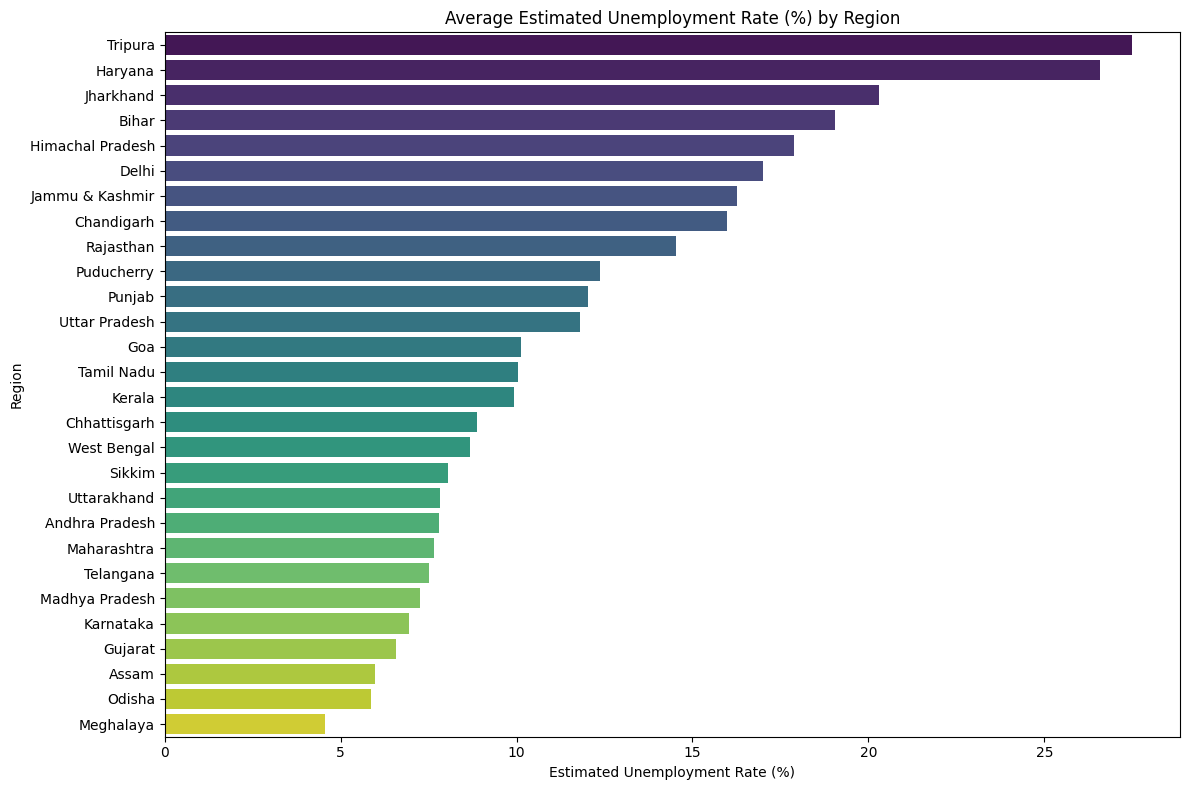

In [46]:
plt.figure(figsize=(12, 8))
sns.barplot(
    x=unemployment_by_region.sort_values(ascending=False).values,
    y=unemployment_by_region.sort_values(ascending=False).index,
    palette='viridis'
)
plt.title('Average Estimated Unemployment Rate (%) by Region')
plt.xlabel('Estimated Unemployment Rate (%)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

Unemployment Analysis by Month

In [47]:
unemployment_by_month = combined_df.groupby(
    "Month"
)["Estimated Unemployment Rate (%)"].mean()

print(unemployment_by_month)

Month
April        23.167013
August        9.865875
December      9.497358
February      9.734810
January       9.702532
July          9.300741
June         10.627176
March        10.728608
May          17.995833
November      9.868364
October       9.283659
September     8.933544
Name: Estimated Unemployment Rate (%), dtype: float64


In [48]:
fig = px.pie(
    names=unemployment_by_month.index,
    values=unemployment_by_month.values,
    title='Average Estimated Unemployment Rate (%) by Month',
    hole=0.3  # Creates a donut chart effect
)
fig.update_traces(textinfo='percent+label', marker=dict(line=dict(color='#000000', width=1)))
fig.show()

Employment Analysis by Region

In [49]:
employment_by_region = combined_df.groupby(
    "Region"
)["Estimated Employed"].mean()

print(
    employment_by_region.sort_values(
        ascending=False
    )
)

Region
Uttar Pradesh       3.531324e+07
Maharashtra         2.504666e+07
West Bengal         2.143712e+07
Bihar               1.532425e+07
Tamil Nadu          1.482701e+07
Gujarat             1.438326e+07
Madhya Pradesh      1.406360e+07
Karnataka           1.355051e+07
Rajasthan           1.259125e+07
Telangana           1.012504e+07
Andhra Pradesh      1.006762e+07
Odisha              8.172349e+06
Assam               6.870190e+06
Punjab              5.656118e+06
Jharkhand           5.601188e+06
Kerala              5.523504e+06
Chhattisgarh        5.387143e+06
Haryana             4.422069e+06
Delhi               3.155226e+06
Jammu & Kashmir     2.252962e+06
Uttarakhand         1.755916e+06
Himachal Pradesh    1.316156e+06
Tripura             8.960261e+05
Meghalaya           8.681364e+05
Chandigarh          3.168312e+05
Goa                 2.898573e+05
Puducherry          2.547739e+05
Sikkim              1.477263e+05
Name: Estimated Employed, dtype: float64


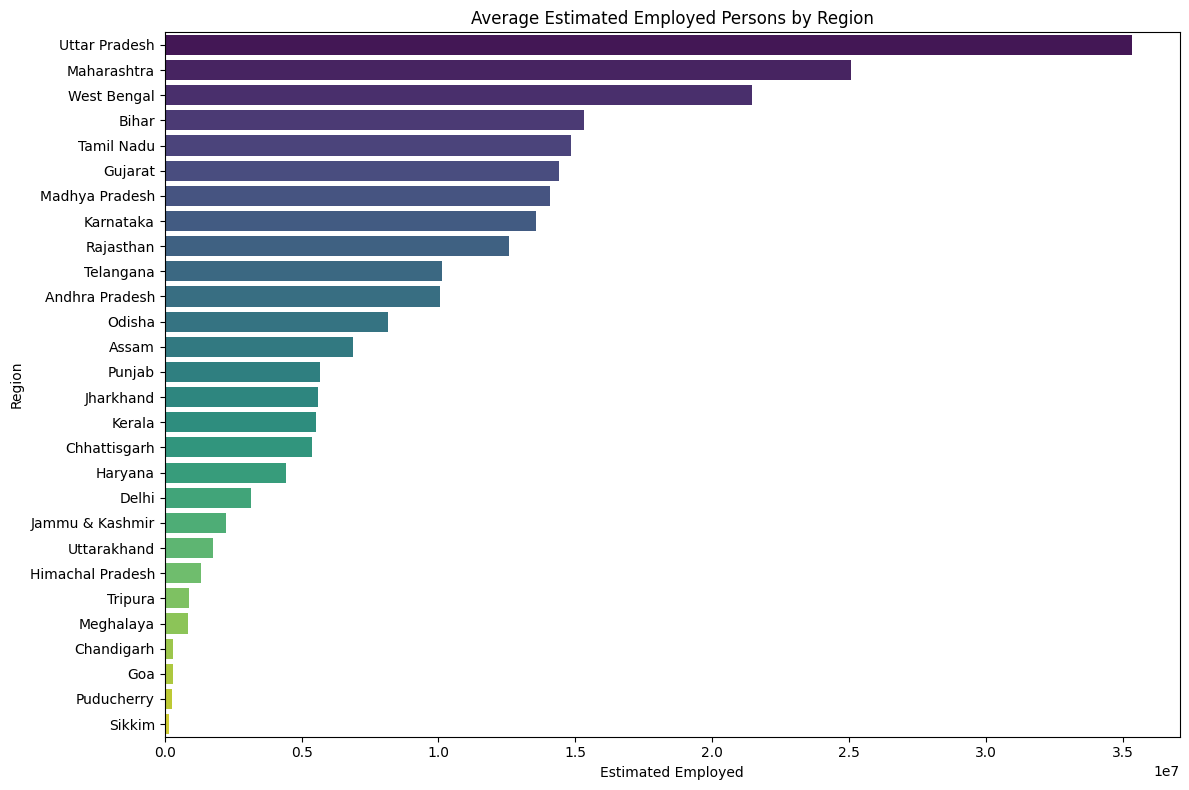

In [50]:
plt.figure(figsize=(12, 8))
sns.barplot(
    x=employment_by_region.sort_values(ascending=False).values,
    y=employment_by_region.sort_values(ascending=False).index,
    palette='viridis'
)
plt.title('Average Estimated Employed Persons by Region')
plt.xlabel('Estimated Employed')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

Employment Analysis by Month

In [51]:
employment_by_month = combined_df.groupby(
    "Month"
)["Estimated Employed"].mean()

print(employment_by_month)

Month
April        7.068500e+06
August       9.864929e+06
December     7.377388e+06
February     1.019882e+07
January      1.029704e+07
July         9.742291e+06
June         8.708906e+06
March        9.916532e+06
May          7.656782e+06
November     7.273661e+06
October      9.695982e+06
September    1.008005e+07
Name: Estimated Employed, dtype: float64


In [52]:
fig = px.pie(
    names=employment_by_month.index,
    values=employment_by_month.values,
    title='Average Estimated Employed Persons by Month',
    hole=0.3  # Creates a donut chart effect
)
fig.update_traces(textinfo='percent+label', marker=dict(line=dict(color='#000000', width=1)))
fig.show()

Top 10 Regions with Highest Unemployment

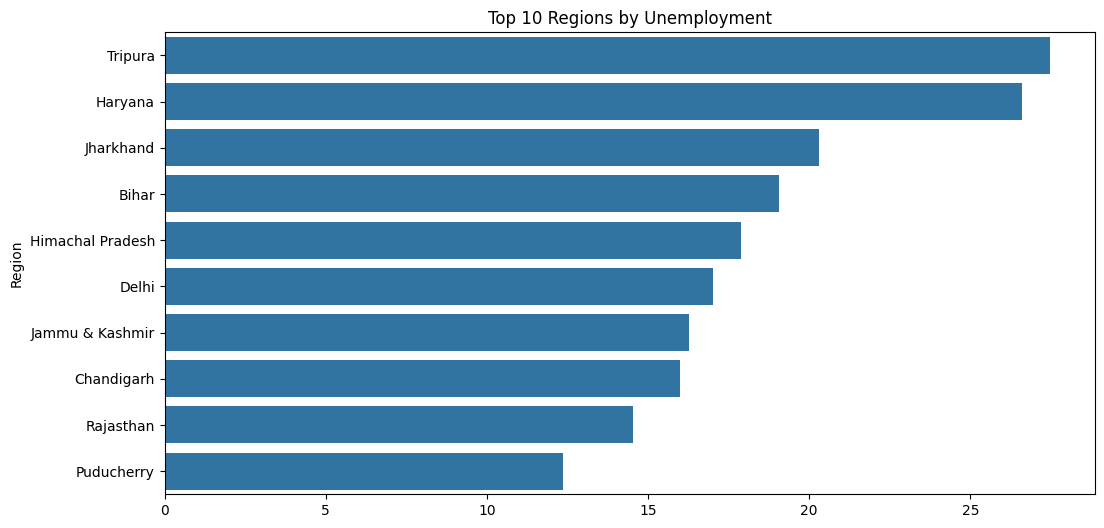

In [53]:
top10 = combined_df.groupby(
    "Region"
)["Estimated Unemployment Rate (%)"].mean()

top10 = top10.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Regions by Unemployment")
plt.show()

Monthly Unemployment Trend

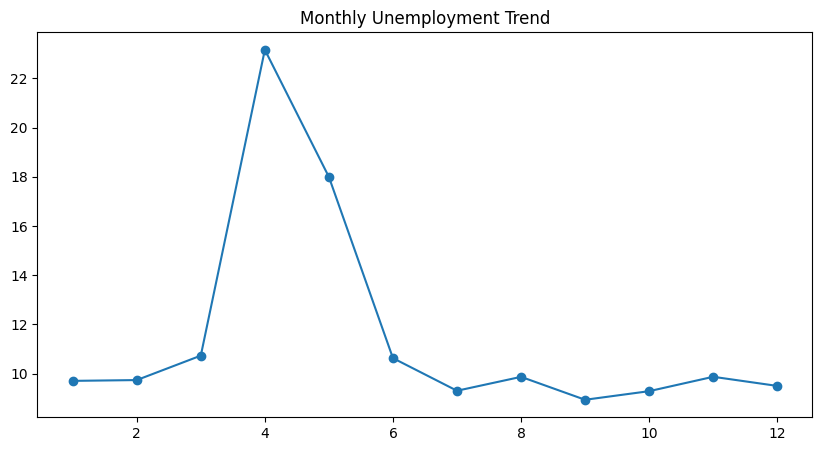

In [54]:
monthly = combined_df.groupby(
    "Month_int"
)["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.title("Monthly Unemployment Trend")
plt.show()

Employment by Region

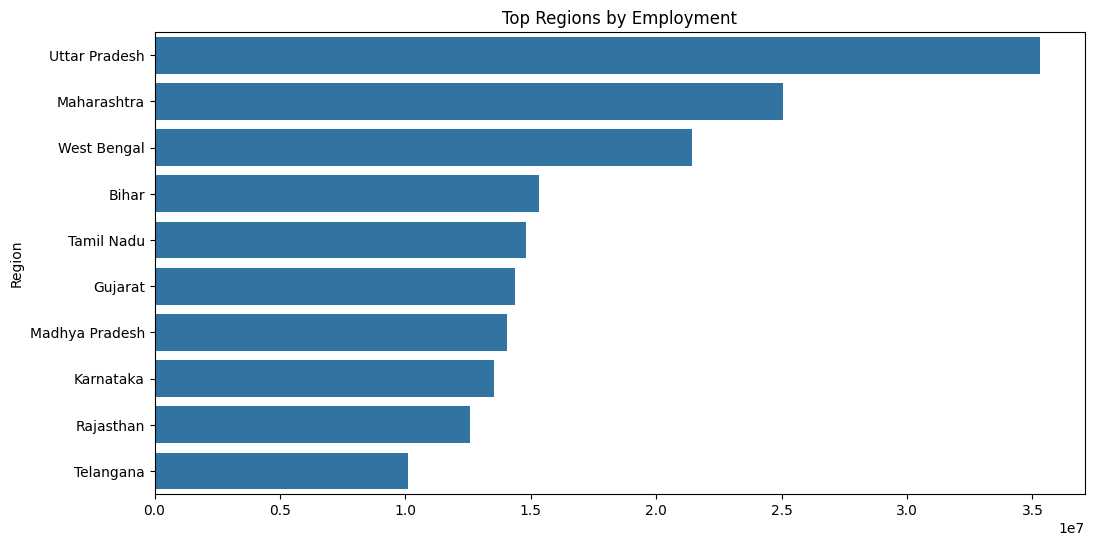

In [55]:
top_emp = combined_df.groupby(
    "Region"
)["Estimated Employed"].mean()

top_emp = top_emp.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_emp.values,
    y=top_emp.index
)

plt.title("Top Regions by Employment")
plt.show()

Correlation Analysis

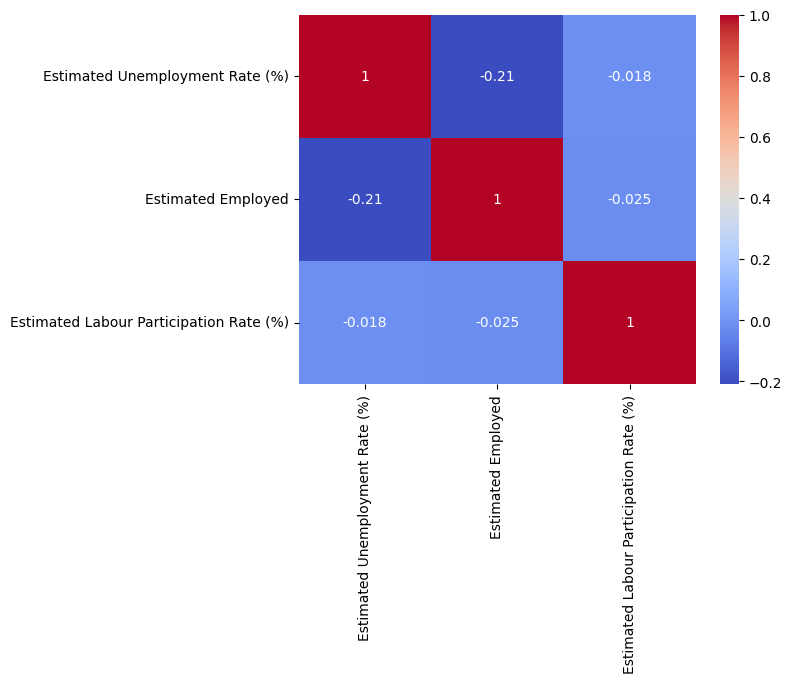

In [56]:
corr = combined_df[
[
'Estimated Unemployment Rate (%)',
'Estimated Employed',
'Estimated Labour Participation Rate (%)'
]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

Histogram Analysis

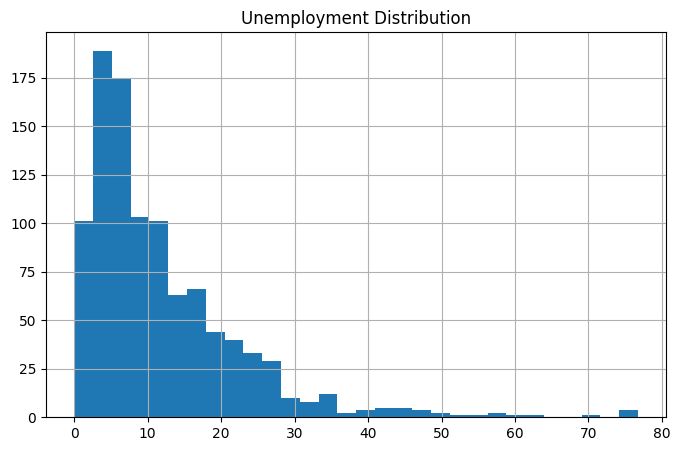

In [57]:
combined_df[
'Estimated Unemployment Rate (%)'
].hist(
    bins=30,
    figsize=(8,5)
)

plt.title("Unemployment Distribution")
plt.show()

Box Plot Analysis

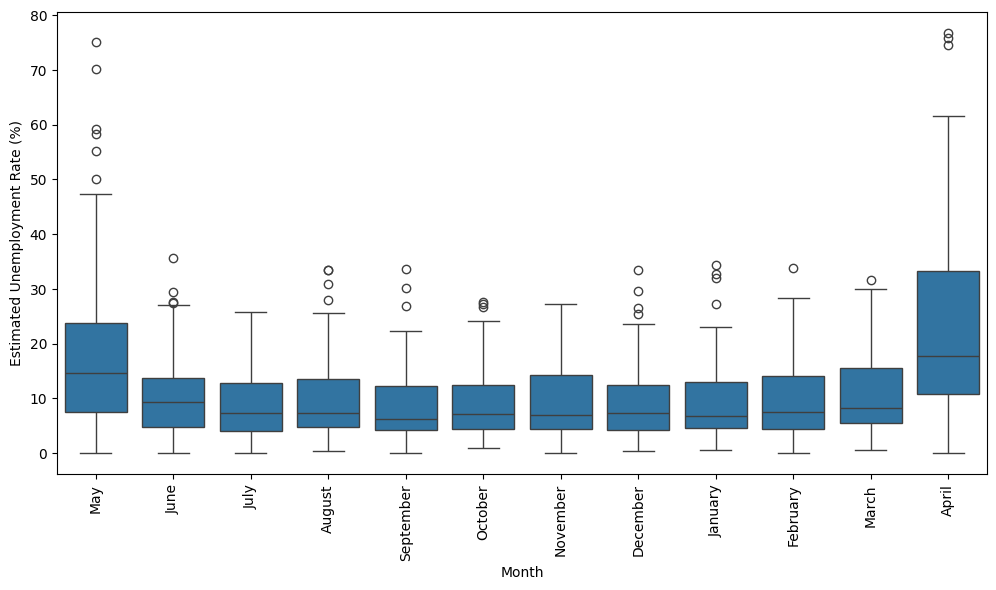

In [58]:
plt.figure(figsize=(12,6))

# Drop rows where 'Date' is NaT before plotting (this should now be minimal or none after date parsing fix)
cleaned_df = combined_df.dropna(subset=['Date']).copy()

sns.boxplot(
    data=cleaned_df,
    x="Month",
    y="Estimated Unemployment Rate (%)"
)

plt.xticks(rotation=90)

plt.show()

Violin Plot Analysis

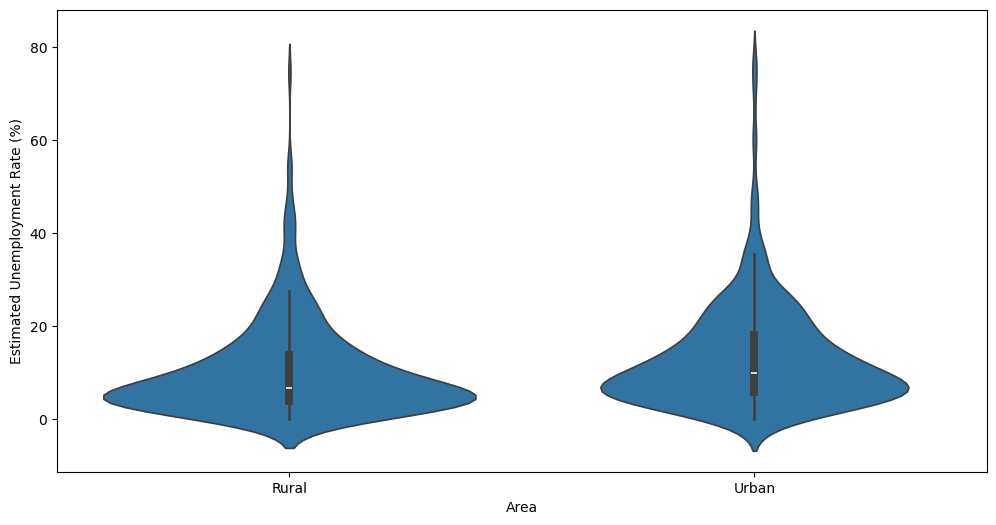

In [59]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=combined_df,
    x="Area",
    y="Estimated Unemployment Rate (%)"
)

plt.show()

scatterplot
   

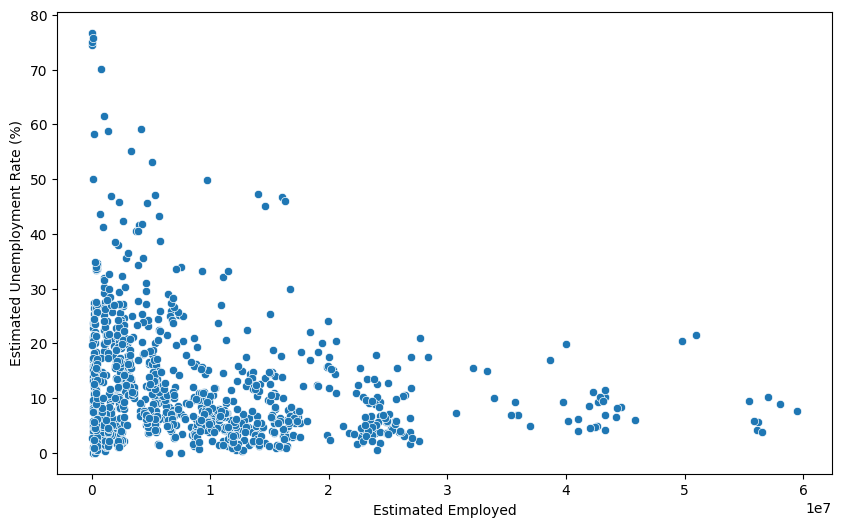

In [60]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=combined_df,
    x="Estimated Employed",
    y="Estimated Unemployment Rate (%)"
)

plt.show()

Rural vs Urban Analysis

In [61]:
rural_urban = combined_df.groupby(
    "Area"
)[
"Estimated Unemployment Rate (%)"
].mean()

print(rural_urban)

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


In [62]:
fig = px.pie(
    names=rural_urban.index,
    values=rural_urban.values,
    title='Unemployment Rate by Area (Rural vs. Urban)',
    hole=0.3  # Creates a donut chart effect
)
fig.update_traces(textinfo='percent+label', marker=dict(line=dict(color='#000000', width=1)))
fig.show()

Sunburst Chart

In [63]:
sunburst_df = combined_df.groupby(
    ["Region","Area"]
)[
"Estimated Unemployment Rate (%)"
].mean().reset_index()

fig = px.sunburst(
    sunburst_df,
    path=["Region","Area"],
    values="Estimated Unemployment Rate (%)",
    color="Estimated Unemployment Rate (%)",
    title="Region Wise Unemployment"
)

fig.show()

COVID-19 Impact Analysis

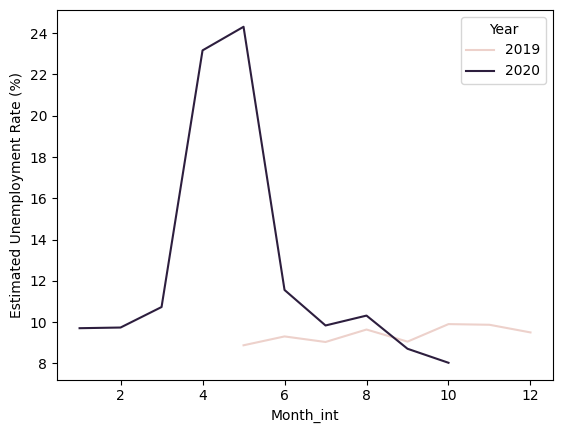

In [64]:
covid = combined_df.groupby(
    ["Year","Month_int"]
)[
"Estimated Unemployment Rate (%)"
].mean().reset_index()

sns.lineplot(
    data=covid,
    x="Month_int",
    y="Estimated Unemployment Rate (%)",
    hue="Year"
)

plt.show()

Feature Engineering

In [65]:
model_df = combined_df[
[
'Region',
'Area',
'Month_int',
'Year',
'Estimated Employed',
'Estimated Labour Participation Rate (%)',
'Estimated Unemployment Rate (%)'
]
]

model_df = model_df.dropna()

Label Encoding

In [66]:
region_encoder = LabelEncoder()

area_encoder = LabelEncoder()

model_df["Region"] = region_encoder.fit_transform(
    model_df["Region"]
)

model_df["Area"] = area_encoder.fit_transform(
    model_df["Area"]
)

Train-Test Split

In [35]:
X = model_df.drop(
    "Estimated Unemployment Rate (%)",
    axis=1
)

y = model_df[
    "Estimated Unemployment Rate (%)"
]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Random Forest Model

Random Forest Regressor:
Mean Absolute Error (MAE): 4.03
Mean Squared Error (RMSE): 7.34
R-squared (R2): 0.63


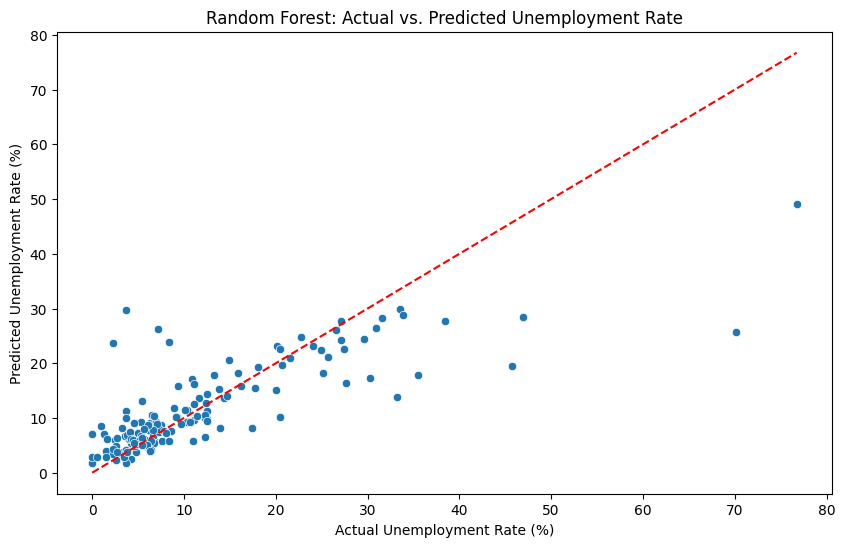

In [67]:
# Train the model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate the model using regression metrics
print("Random Forest Regressor:")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"R-squared (R2): {r2_score(y_test, y_pred_rf):.2f}")

# Plotting actual vs predicted values (regression visualization)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual Unemployment Rate (%)")
plt.ylabel("Predicted Unemployment Rate (%)")
plt.title("Random Forest: Actual vs. Predicted Unemployment Rate")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Reference line
plt.show()

XGBoost Model

XGBoost Regressor:
Mean Absolute Error (MAE): 4.14
Mean Squared Error (RMSE): 7.48
R-squared (R2): 0.61


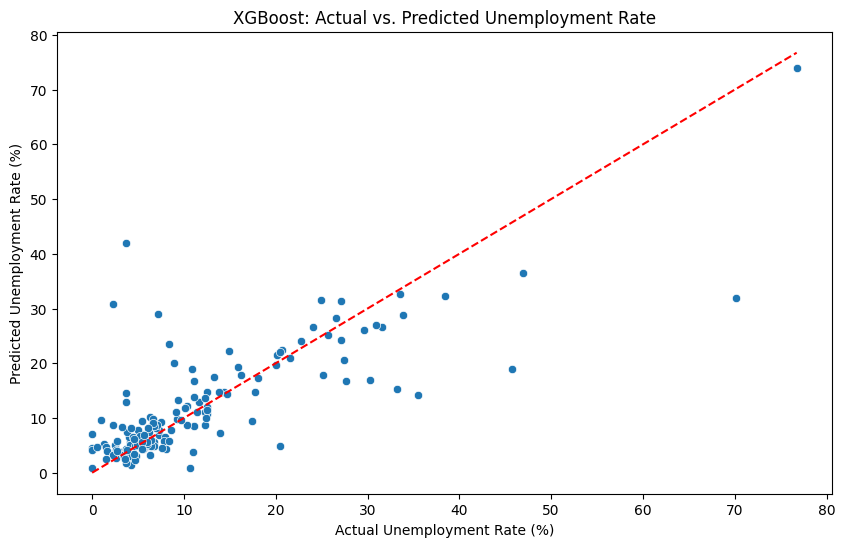

In [68]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

# Evaluate the model using regression metrics
print("XGBoost Regressor:")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, xgb_pred):.2f}")
print(f"Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, xgb_pred)):.2f}")
print(f"R-squared (R2): {r2_score(y_test, xgb_pred):.2f}")

# Plotting actual vs predicted values (regression visualization)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=xgb_pred)
plt.xlabel("Actual Unemployment Rate (%)")
plt.ylabel("Predicted Unemployment Rate (%)")
plt.title("XGBoost: Actual vs. Predicted Unemployment Rate")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Reference line
plt.show()

Compare Models

In [69]:
models = {
    "Random Forest":y_pred_rf,
    "XGBoost":xgb_pred
}

for name,pred in models.items():

    print("\n",name)

    print(
        "MAE:",
        mean_absolute_error(y_test,pred)
    )

    print(
        "RMSE:",
        np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        )
    )

    print(
        "R2:",
        r2_score(
            y_test,
            pred
        )
    )



 Random Forest
MAE: 4.0324374999999995
RMSE: 7.341364971535412
R2: 0.6277352343230957

 XGBoost
MAE: 4.135097108000034
RMSE: 7.478541245011553
R2: 0.6136934351241061


Feature Importance

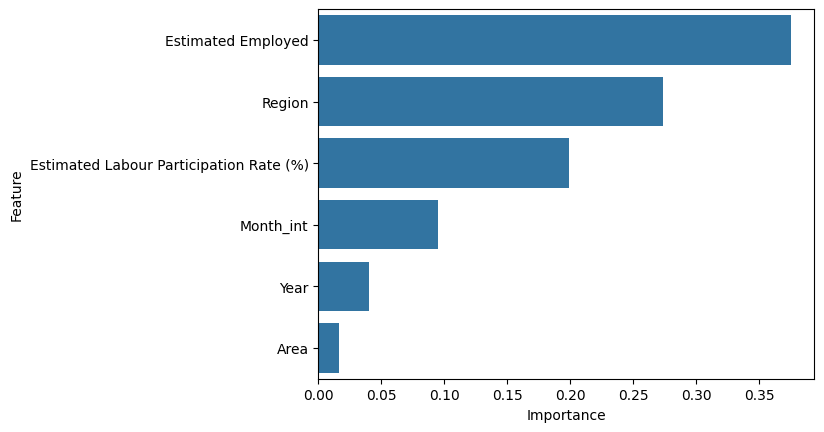

In [70]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.show()

Save Model

In [71]:
joblib.dump(
    rf,
    "unemployment_model.pkl"
)

joblib.dump(
    region_encoder,
    "region_encoder.pkl"
)

joblib.dump(
    area_encoder,
    "area_encoder.pkl"
)

['area_encoder.pkl']

Create Prediction Function

In [72]:
model = joblib.load(
    "unemployment_model.pkl"
)

def predict_unemployment(
    region,
    area,
    month,
    year,
    employed,
    labour_rate
):

    region = region_encoder.transform(
        [region]
    )[0]

    area = area_encoder.transform(
        [area]
    )[0]

    prediction = model.predict([[
        region,
        area,
        month,
        year,
        employed,
        labour_rate
    ]])

    return round(
        prediction[0],
        2
    )

Build Gradio Interface

In [73]:
app = gr.Interface(
    fn=predict_unemployment,

    inputs=[
        gr.Dropdown(
            region_encoder.classes_.tolist(),
            label="Region"
        ),

        gr.Dropdown(
            area_encoder.classes_.tolist(),
            label="Area"
        ),

        gr.Slider(
            1,
            12,
            step=1,
            label="Month"
        ),

        gr.Number(
            label="Year"
        ),

        gr.Number(
            label="Estimated Employed"
        ),

        gr.Number(
            label="Labour Participation Rate"
        )
    ],

    outputs="text",

    title="Unemployment Prediction System"
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b364081c12b908c588.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
